# Objetivo
O objetivo desse problema é investigar como fatores demográficos, sociais e hábitos influenciam nos custos de plano de saúde (Inferência e Modelagem). Além de desenvolver um modelo preditivo para estimar os valores para novos usuários (Machine Learning).
A origem dos dados é o repositorio na plataforma [Kaggle](https://www.kaggle.com/datasets/mosapabdelghany/medical-insurance-cost-dataset).  
Para isso, temos como variáveis explicativas: age, sex, bmi, children, smoker and region. Enquanto nossa variável alvo é charges.  

### Inferência e Modelagem
H0: O coeficiente da variável é 0. Ou seja, não possui efeito estatisticamente significante sob o custo (charge).  
H1: O coeficiente da variável é diferente de 0. A variável explica estatitcamente significante a variável alvo (charges). 

### Machine Learning  
Prever os custos estimados para novos usuários.  
Modelos utilizados:  
- Linear Regression: Modelo que tenta ajustar os dados a uma reta, assumindo um padrão aditivo e linear entre X e Y  
- Decision Tree: Representa um fluxograma de escolhas, onde os dados são segmentados de modo homogeneo.  
- Random Forest: Utiliza centenas de decision Trees como o método Bagging (de modo independente), reduzindo a variância e sendo mais assertivo.

# 1) EDA

In [13]:
#Importar Bibliotecas
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from statsmodels.stats.power import TTestIndPower

#Definir acesso do arquivo
path = 'dataset/insurance.csv'

#Criar df
df = pd.read_csv(path)

#df criado, vamos entende-lo melhror
print(df.head(5))

   age     sex     bmi  children smoker     region      charges
0   19  female  27.900         0    yes  southwest  16884.92400
1   18    male  33.770         1     no  southeast   1725.55230
2   28    male  33.000         3     no  southeast   4449.46200
3   33    male  22.705         0     no  northwest  21984.47061
4   32    male  28.880         0     no  northwest   3866.85520


Columns

age: Age of primary beneficiary (int)

sex: Gender of beneficiary (male, female)

bmi: Body Mass Index, a measure of body fat based on height and weight (float)

children: Number of children covered by health insurance (int)

smoker: Smoking status of the beneficiary (yes, no)

region: Residential region in the US (northeast, northwest, southeast, southwest)

charges: Medical insurance cost billed to the beneficiary (float)



In [14]:
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   object 
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   object 
 5   region    1338 non-null   object 
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), object(3)
memory usage: 73.3+ KB
None


Conforme apresentado, não há registros nulo/ausentes. Então vamos analisar a distribuição dos dados e possiveis outliers.

array([[<Axes: title={'center': 'age'}>, <Axes: title={'center': 'bmi'}>],
       [<Axes: title={'center': 'children'}>,
        <Axes: title={'center': 'charges'}>]], dtype=object)

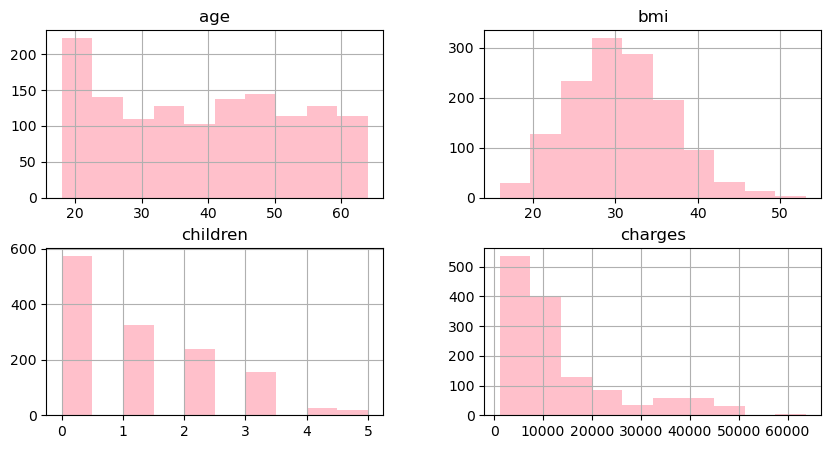

In [15]:
df.hist(bins=10, figsize=(10,5), facecolor = 'pink')

Com essa distribuição conclui-se que Charges apresenta uma queda significativa após o valor de 15000, e bmi tem poucos registros <20 e >40. Logo, para melhor visualização, vamos analisar os quartis.

In [16]:
df.describe()

,age,bmi,children,charges
count,1338.000000,1338.000000,1338.000000,1338.000000
mean,39.207025,30.663397,1.094918,13270.422265
std,14.049960,6.098187,1.205493,12110.011237
min,18.000000,15.960000,0.000000,1121.873900
25%,27.000000,26.296250,0.000000,4740.287150
50%,39.000000,30.400000,1.000000,9382.033000
75%,51.000000,34.693750,2.000000,16639.912515
max,64.000000,53.130000,5.000000,63770.428010


## 1.1) Boxplot  
### A) Charges

<function matplotlib.pyplot.show(close=None, block=None)>

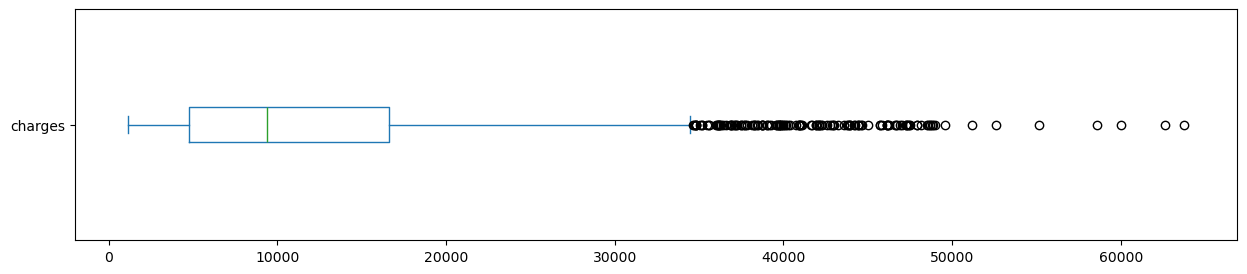

In [17]:
df.charges.plot(kind= 'box', vert = False, figsize=(15,3))
plt.show

In [19]:
Q1 = df['charges'].quantile(q = 0.25)
Q3 = df['charges'].quantile(q = 0.75)
DQ = Q3-Q1

LS = round(Q3 + 1.5*DQ, 2)
LI = round(Q1 - 1.5*DQ,2)

print(f'O valor do Limite superior é {LS} enquanto o valor do Limite Inferior é {LI}')
print(f'Existem {len(df[df["charges"] > LS])} registros acima de {LS}')
LS_Charges = LS

O valor do Limite superior é 34489.35 enquanto o valor do Limite Inferior é -13109.15
Existem 139 registros acima de 34489.35


### B) BMI

<function matplotlib.pyplot.show(close=None, block=None)>

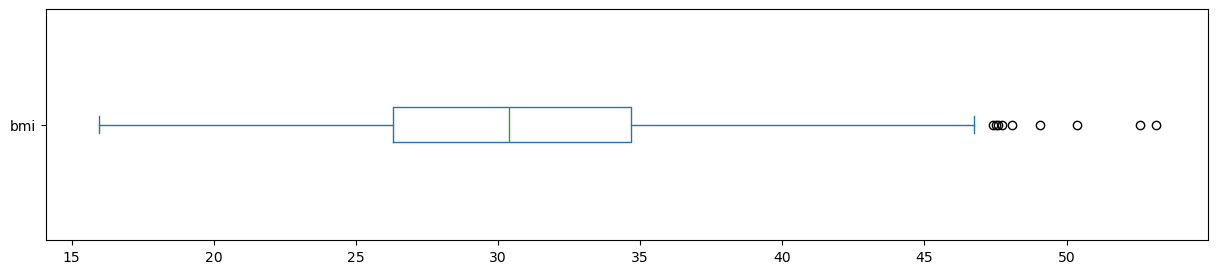

In [ ]:
df.bmi.plot(kind= 'box', vert = False, figsize=(15,3))
plt.show

In [20]:
Q1 = df['bmi'].quantile(q = 0.25)
Q3 = df['bmi'].quantile(q = 0.75)
DQ = Q3-Q1

LS = round(Q3 + 1.5*DQ, 2)
LI = round(Q1 - 1.5*DQ,2)

print(f'O valor do Limite superior é {LS} enquanto o valor do Limite Inferior é {LI}')
print(f'Existem {len(df[df["bmi"] > LS])} registros acima de {LS}')
LS_bmi = LS

O valor do Limite superior é 47.29 enquanto o valor do Limite Inferior é 13.7
Existem 9 registros acima de 47.29


## 1.2) Outliers e Tamanho da Amostra

Vamos entender se há individuos pertencentes aos outliers de Charges e BMI simultaneamente.

In [21]:
df_check = df[ 
    (df['charges'] >= LS_Charges) & 
    (df['bmi'] >= LS_bmi)
]
df_check

,age,sex,bmi,children,smoker,region,charges
543,54,female,47.41,0,yes,southeast,63770.42801
860,37,female,47.60,2,yes,southwest,46113.51100
1047,22,male,52.58,1,yes,southeast,44501.39820


Agora, é sensato estimar qual o tamanho da amostra para assim entender o valor do poder que diz respeito a probabilidade de rejeitar corretamente H0.

In [ ]:
analysis = TTestIndPower()
tamanho_amostra = analysis.solve_power(
    effect_size=0.5, #efeito esperado
    alpha=0.05,
    power=0.8,
    nobs1=None # tamanho ideal da amostra
)
tamanho_amostra = round(tamanho_amostra,0)

print(f'O tamanho ideal da amostra é {tamanho_amostra}')

O tamanho ideal da amostra é 64.0


Logo, para um resultado satisfatorio sendo um efeito de tamanho médio a quantidade que temos de dados é muito maior.  
Todavia, sabendo que, há cerca 139 possiveis outliers para Charges, cerca de 10% dos dados, enquanto que para bmi há 9 registros, eliminar todos de uma só vez representa uma grande perca do dataset.  
Dessa forma, optou-se inicialmente por remover apenas as observações que apresentam outliers simultaneamente em ambas as variáveis (bmi e charges), originando o que será denominado como Dataset Tratado (df_clean)

In [ ]:
df_clean = df[
    (df['charges'] < LS_Charges) & 
    (df['bmi'] < LS_bmi)
]

df_clean

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520
...,...,...,...,...,...,...,...
1333,50,male,30.970,3,no,northwest,10600.54830
1334,18,female,31.920,0,no,northeast,2205.98080
1335,18,female,36.850,0,no,southeast,1629.83350
1336,21,female,25.800,0,no,southwest,2007.94500


É importante ressaltar que o dataset tratado não representa necessariamente a escolha final para a modelagem. Modelos de regressão estatística serão aplicados tanto no dataset original quanto no tratado, permitindo a comparação de desempenho entre ambos e a seleção da abordagem mais adequada.  
Para entender melhor as variáveis, vamos analisar as correlações existentes e também verificar se existe alguma multicolenearidade.

## 1.3 Analise de correlação e multicolenearidade
### A) **Dataset tratado**

In [13]:
# Transformar qualitativas em binárias
df_corr = pd.get_dummies(df_clean, columns=['sex', 'region', 'smoker'], drop_first=True)
df_corr.columns

Index(['age', 'bmi', 'children', 'charges', 'sex_male', 'region_northwest',
       'region_southeast', 'region_southwest', 'smoker_yes'],
      dtype='object')

In [14]:
corr = df_corr[[
    'age', 'bmi', 'children', 'charges', 
    'sex_male', 'region_northwest','region_southeast', 
    'region_southwest', 'smoker_yes'
]].corr()

corr

,age,bmi,children,charges,sex_male,region_northwest,region_southeast,region_southwest,smoker_yes
age,1.000000,0.122592,0.039967,0.436815,-0.021146,-0.001008,-0.017612,0.016157,-0.067387
bmi,0.122592,1.000000,0.006796,-0.061033,0.016431,-0.112714,0.230967,0.014022,-0.256624
children,0.039967,0.006796,1.000000,0.083093,0.015504,0.012522,-0.015572,0.025880,-0.006034
charges,0.436815,-0.061033,0.083093,1.000000,-0.022511,0.034066,-0.025553,-0.072158,0.602360
sex_male,-0.021146,0.016431,0.015504,-0.022511,1.000000,0.004640,-0.005127,-0.003761,0.014037
region_northwest,-0.001008,-0.112714,0.012522,0.034066,0.004640,1.000000,-0.341199,-0.332879,0.016336
region_southeast,-0.017612,0.230967,-0.015572,-0.025553,-0.005127,-0.341199,1.000000,-0.330680,0.000399
region_southwest,0.016157,0.014022,0.025880,-0.072158,-0.003761,-0.332879,-0.330680,1.000000,-0.046755
smoker_yes,-0.067387,-0.256624,-0.006034,0.602360,0.014037,0.016336,0.000399,-0.046755,1.000000


<function matplotlib.pyplot.show(close=None, block=None)>

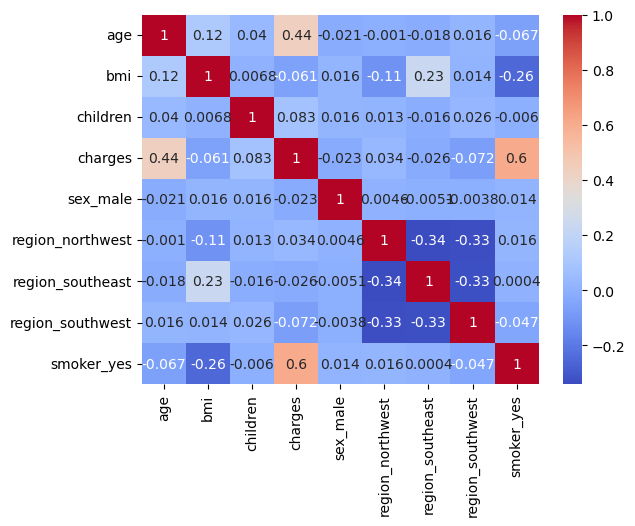

In [15]:
sns.heatmap(
    corr, annot=True, cmap='coolwarm'
)
plt.show

smoker_yes > age > children

O dataset tratado apresenta duas variáveis fortemente explicativas e um possível terceira, smoker_yes, age e children respectivamente. Porém para termoz mais certeza, vamos precisar da regressão estatistica.

### B) **Dataset Original**

In [16]:
# Transformar qualitativas em binárias
df_corr = pd.get_dummies(df, columns=['sex', 'region', 'smoker'], drop_first=True)
df_corr.columns

Index(['age', 'bmi', 'children', 'charges', 'sex_male', 'region_northwest',
       'region_southeast', 'region_southwest', 'smoker_yes'],
      dtype='object')

In [17]:
corr = df_corr[[
    'age', 'bmi', 'children', 'charges', 
    'sex_male', 'region_northwest','region_southeast', 
    'region_southwest', 'smoker_yes'
]].corr()

corr

,age,bmi,children,charges,sex_male,region_northwest,region_southeast,region_southwest,smoker_yes
age,1.000000,0.109272,0.042469,0.299008,-0.020856,-0.000407,-0.011642,0.010016,-0.025019
bmi,0.109272,1.000000,0.012759,0.198341,0.046371,-0.135996,0.270025,-0.006205,0.003750
children,0.042469,0.012759,1.000000,0.067998,0.017163,0.024806,-0.023066,0.021914,0.007673
charges,0.299008,0.198341,0.067998,1.000000,0.057292,-0.039905,0.073982,-0.043210,0.787251
sex_male,-0.020856,0.046371,0.017163,0.057292,1.000000,-0.011156,0.017117,-0.004184,0.076185
region_northwest,-0.000407,-0.135996,0.024806,-0.039905,-0.011156,1.000000,-0.346265,-0.320829,-0.036945
region_southeast,-0.011642,0.270025,-0.023066,0.073982,0.017117,-0.346265,1.000000,-0.346265,0.068498
region_southwest,0.010016,-0.006205,0.021914,-0.043210,-0.004184,-0.320829,-0.346265,1.000000,-0.036945
smoker_yes,-0.025019,0.003750,0.007673,0.787251,0.076185,-0.036945,0.068498,-0.036945,1.000000


<function matplotlib.pyplot.show(close=None, block=None)>

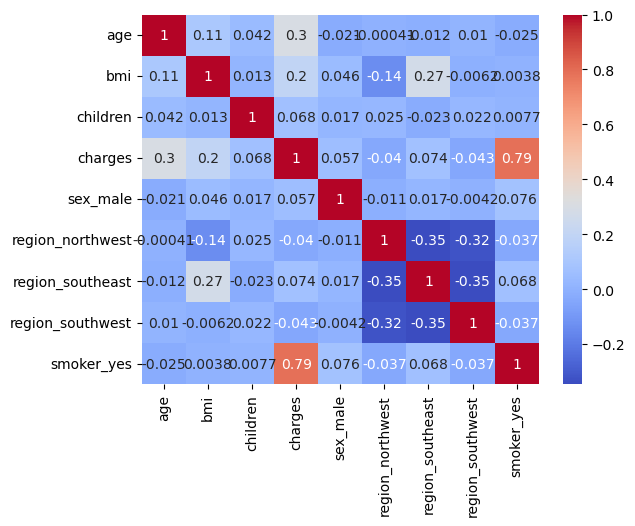

In [18]:
sns.heatmap(
    corr, annot=True, cmap='coolwarm'
)
plt.show

smoker_yes > age > ibm

É comum que, o ato de fumar está diretamente ligado ao custo do seguro de saúde dado que, novamente, smoker_yes tem maior correlação e aumento 0.19. Com resultado semelhante ao anterior, o dataset original se diferencia pela 3 variável com maior correlação que nesse caso é IBM.

Text(0.5, 1.0, 'Custo x Ato de Fumar')

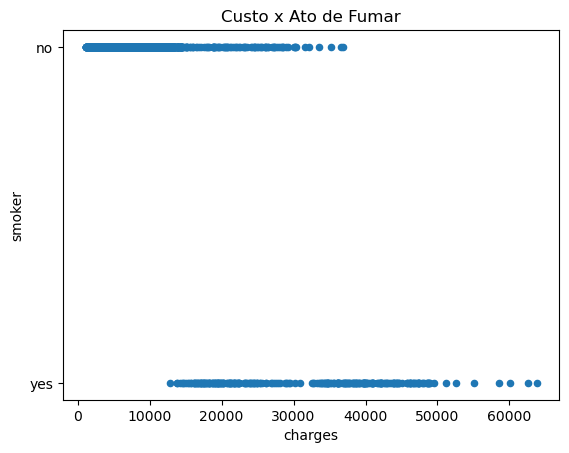

In [ ]:
df.plot.scatter('charges', 'smoker')
plt.title('Custo x Ato de Fumar')

Importante lembrar que correlação é diferente de causalidade.


**Para conclusão final de inferência vamos aplicar a modelagem abaixo.**

In [20]:
df_clean.columns

Index(['age', 'sex', 'bmi', 'children', 'smoker', 'region', 'charges'], dtype='object')

# 2) Regressão estatistíca

1. **Modelagem:**
Coeficiente: variação do valor da variável alvo dado o aumento em uma unidade daquela variavel explicativa  
p-value: probabilidade de observar os dados resultantes, dado que H0 é verdadeira  
estatistica t: valor que indica a força e significância da variavel explicativa com o alvo  
Skew: valor que indica sentindo da cauda de outlier,aproximadamente 0  
Kurtosis: valor que indica intensidade das caudas, o ideal é aproximadamente 3  
Prob(JB) e Prob(Omnibus): indicam se há normalidade nos dados, ideal é > 0,05  

2. **Gráficos:**
Histograma de Residuos: indicam se o o erro segue distribuiçao normal e se há outliers (caudas)  
QQ Plot: indica se os residuos se adaptam a uma distribuiçao normal  
Residuos x Previsto: indicam se o modelo representa a realidade, através dos erros seguindo um padrão aleatorio em torno de 0, tendo com H0 uma distribuiçao normal ou homogenea

## 2.1) Dataset tratado

### A. Modelagem

In [21]:
import statsmodels.api as sm
import statsmodels.formula.api as smf
from statsmodels.stats.diagnostic import het_breuschpagan
from scipy import stats

In [22]:
results = smf.ols(
    'charges ~' \
    'age + ' \
    'sex + ' \
    'bmi + ' \
    'children +' \
    'smoker + ' \
    'region',
    data = df_clean
).fit()

results.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                charges   R-squared:                       0.604
Model:                            OLS   Adj. R-squared:                  0.602
Method:                 Least Squares   F-statistic:                     226.0
Date:                Thu, 02 Apr 2026   Prob (F-statistic):          3.56e-232
Time:                        15:26:25   Log-Likelihood:                -11744.
No. Observations:                1193   AIC:                         2.351e+04
Df Residuals:                    1184   BIC:                         2.355e+04
Df Model:                           8                                         
Covariance Type:            nonrobust                                         
=======================================================================================
                          coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------------
Intercept           -3071.1820    826.381     -3.716      0.000   -4692.516   -1449.848
sex[T.male]          -351.9989    265.317     -1.327      0.185    -872.543     168.545
smoker[T.yes]        1.466e+04    430.007     34.101      0.000    1.38e+04    1.55e+04
region[T.northwest]  -291.6272    373.898     -0.780      0.436   -1025.203     441.949
region[T.southeast] -1045.3948    385.097     -2.715      0.007   -1800.944    -289.846
region[T.southwest] -1330.3238    380.061     -3.500      0.000   -2075.991    -584.656
age                   242.2389      9.525     25.433      0.000     223.552     260.926
bmi                    75.3440     24.349      3.094      0.002      27.572     123.116
children              414.1553    109.164      3.794      0.000     199.978     628.332
==============================================================================
Omnibus:                      744.987   Durbin-Watson:                   2.063
Prob(Omnibus):                  0.000   Jarque-Bera (JB):             5164.701
Skew:                           3.001   Prob(JB):                         0.00
Kurtosis:                      11.239   Cond. No.                         325.
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

### B. Gráficos


<function matplotlib.pyplot.show(close=None, block=None)>

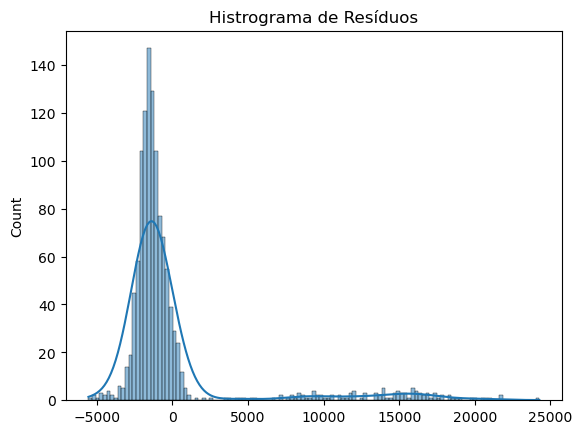

In [ ]:
sns.histplot(results.resid, kde= True)
plt.title('Histrograma de Resíduos')
plt.show

<function matplotlib.pyplot.show(close=None, block=None)>

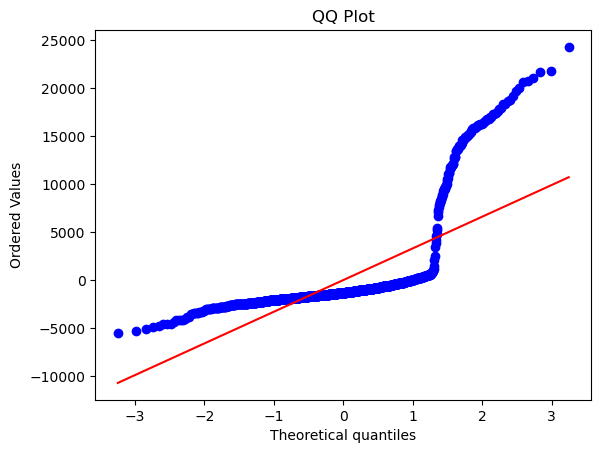

In [ ]:
stats.probplot(results.resid, dist = 'norm', plot = plt)
plt.title('QQ Plot')
plt.show


<function matplotlib.pyplot.show(close=None, block=None)>

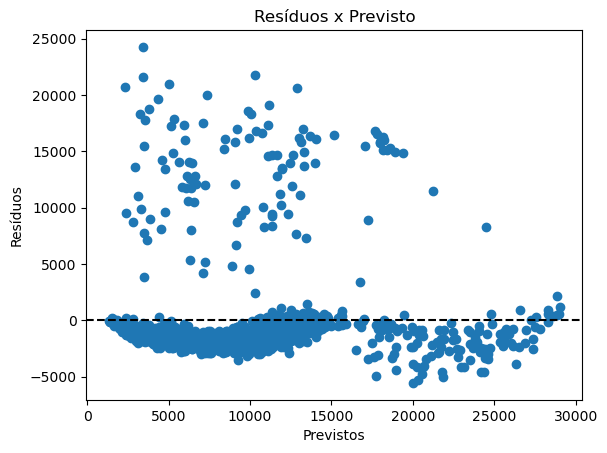

In [ ]:
plt.scatter(results.fittedvalues, results.resid)
plt.title('Resíduos x Previsto')
plt.axhline(y=0, color='black', linestyle='--') # Linha de erro zero
plt.xlabel('Previstos')
plt.ylabel('Resíduos')
plt.show

O histrograma indica que ainda que os erros sigam uma distribuiçao normal há outliers concentrados na cauda direita.  
Além disso, o QQ Plot mostra que os dados não tendem a uma distrbuiçao normal visto o não alinhamento dos dados a reta.  
E por fim, o grafico de Residuo x Previsto indica um formato semelhante a V nvertido descartando totalmente a ideia de de distrbuiçao normal e linear


### C. Heterocedasticidade

In [ ]:
test_h = het_breuschpagan(results.resid, exog_het = results.model.exog)
print('p-value:', test_h[1])

p-value: 0.03546575840748071


O valor obtido para heterocedasticidade indica que a variância do erro não é constante conforme as caracteristica de risco de cada usuário.

### D. Conclusão: 
O modelo apresentou um R² medianamente significativo (0.604). O que indica o que reafirma a possibilidade de as variaveis serem realmente explicativas. Todavia, essa informação ainda é insuficiente.
Logo, partimos para olhar os demais reafirmando o que foi apresentado anteriormente, o ato de fumar está fortemente relacionado ao valor do seguro conforme evidenciado pelo Coeficiente (1.466e+04), pvalue(0.000), e por fim, estatistica t(34.101) com o maior valor dentre todas as variáveis. 
O mesmo acontece para variável age com Coeficiente (242.2389), pvalue(0.000), estatistica t(25.433) e variavel children que dispõe de Coeficiente (414.1553), pvalue(0.000), estatistica t(3.794)  
### Resíduos:
Prob(JB) = 0  
Prob (Omnibus) = 0  
Skew = 3.001  
Kurtosis = 11.239  
Analisando Prob(JB) e Prob (Omnibus), Skew e Kurtosis fica claro que não existe normalidade nos dados e sim caudas pesadas para a direita, o que já era esperado dado a distribuição e contexto dos dados.


## 2.2 Dataset original

### A. Modelagem

In [27]:
results = smf.ols(
    'charges ~' \
    'age + ' \
    'sex + ' \
    'bmi + ' \
    'children +' \
    'smoker + ' \
    'region',
    data = df
).fit()

results.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                charges   R-squared:                       0.751
Model:                            OLS   Adj. R-squared:                  0.749
Method:                 Least Squares   F-statistic:                     500.8
Date:                Thu, 02 Apr 2026   Prob (F-statistic):               0.00
Time:                        15:26:30   Log-Likelihood:                -13548.
No. Observations:                1338   AIC:                         2.711e+04
Df Residuals:                    1329   BIC:                         2.716e+04
Df Model:                           8                                         
Covariance Type:            nonrobust                                         
=======================================================================================
                          coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------------
Intercept           -1.194e+04    987.819    -12.086      0.000   -1.39e+04      -1e+04
sex[T.male]          -131.3144    332.945     -0.394      0.693    -784.470     521.842
smoker[T.yes]        2.385e+04    413.153     57.723      0.000     2.3e+04    2.47e+04
region[T.northwest]  -352.9639    476.276     -0.741      0.459   -1287.298     581.370
region[T.southeast] -1035.0220    478.692     -2.162      0.031   -1974.097     -95.947
region[T.southwest]  -960.0510    477.933     -2.009      0.045   -1897.636     -22.466
age                   256.8564     11.899     21.587      0.000     233.514     280.199
bmi                   339.1935     28.599     11.860      0.000     283.088     395.298
children              475.5005    137.804      3.451      0.001     205.163     745.838
==============================================================================
Omnibus:                      300.366   Durbin-Watson:                   2.088
Prob(Omnibus):                  0.000   Jarque-Bera (JB):              718.887
Skew:                           1.211   Prob(JB):                    7.86e-157
Kurtosis:                       5.651   Cond. No.                         311.
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

### B. Gráficos

<function matplotlib.pyplot.show(close=None, block=None)>

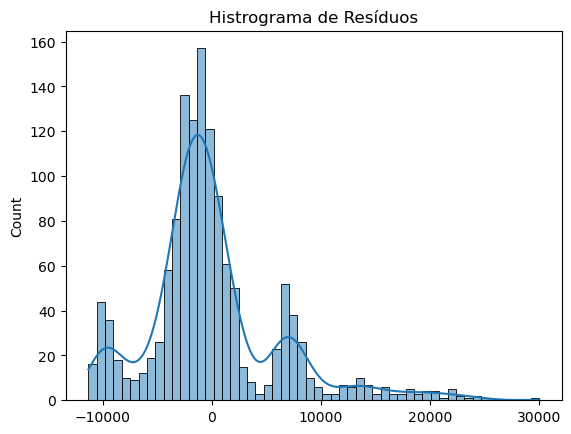

In [ ]:
sns.histplot(results.resid, kde= True)
plt.title('Histrograma de Resíduos')
plt.show

Entendendo a presença de 3 picos invés de 1

<function matplotlib.pyplot.show(close=None, block=None)>

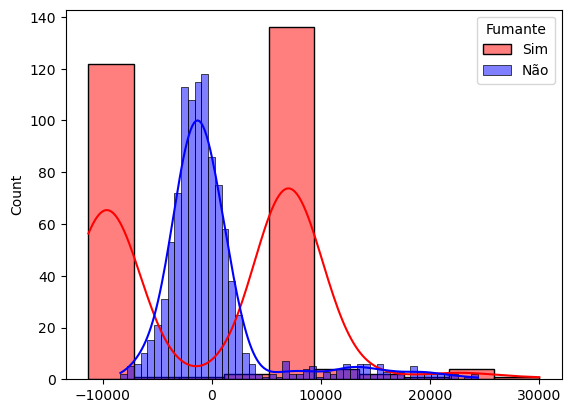

In [ ]:
sns.histplot(results.resid[df['smoker'] == 'yes'], color='red', kde=True, label = 'Sim')
sns.histplot(results.resid[df['smoker'] == 'no'], color='blue', kde=True, label = 'Não')
plt.legend(title= 'Fumante')
plt.show

<function matplotlib.pyplot.show(close=None, block=None)>

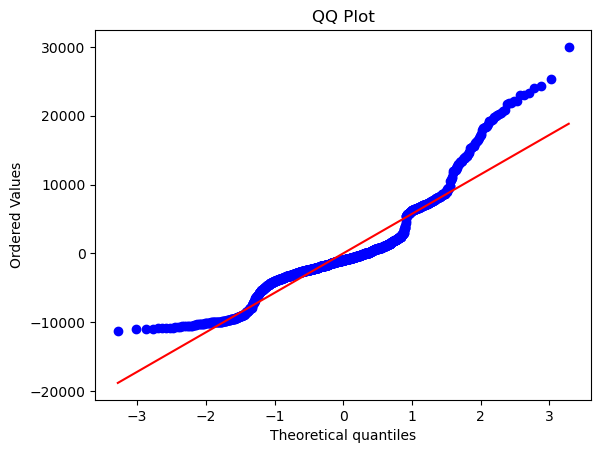

In [ ]:
stats.probplot(results.resid, dist = 'norm', plot = plt)
plt.title('QQ Plot')
plt.show


<function matplotlib.pyplot.show(close=None, block=None)>

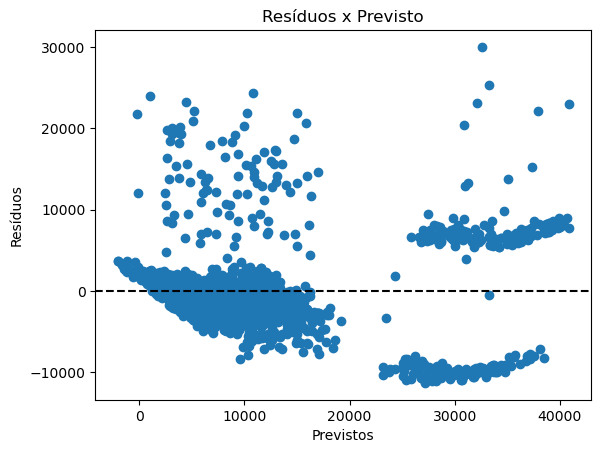

In [ ]:
plt.scatter(results.fittedvalues, results.resid)
plt.title('Resíduos x Previsto')
plt.axhline(y=0, color='black', linestyle='--') # Linha de erro zero
plt.xlabel('Previstos')
plt.ylabel('Resíduos')
plt.show

O histograma indicou a presença de heterogeneidade (inconcsistência ou diferença significativa entre os resultados). O que já era esperado visto que algumas variáveis tendem a ter comportamento bem diferentes diante de charges (Por exemplo: fumantes x não fuumantes).  
Enquanto isso, o gráfico QQ Plot indica uma normalidade baixa além de caudas pesadas, oriundas dos charges de valores elvados não removidos.  
Por fim, a comparação entre Resíduos x Previsto indica que não há variância homogênea, linearidade além de que está sendo clusterizado em grupos distintos.

### C. Heterocedasticidade

In [ ]:
test_h = het_breuschpagan(results.resid, exog_het = results.model.exog)
print('p-value:', test_h[1])
print('ideal é > 0,05')

p-value: 1.4467175539183832e-22
ideal é > 0,05


O valor obtido para heterocedasticidade indica que a variância do erro não é nada constante.

### D. Conclusão
O modelo apresentou um R²(0.751) maior que torna esse dataset mais competitivo.
Conforme previamente calculado pela correlação, o ato de fumar é o maior relacionado ao custo do valor do seguro de saúde, visto que apresenta maior coeficiente (2.385e+04), um p value minimo(0.000) e a maior estatistica t(57.723). Lembrando que pela correlação temos que age > bmi > children, com o calculo da regressão entedemos que bmi tem valor maior de explicação dado que seu coeficiente é maior ainda que o intervalo de variação seja menor. Explicando melhor:  
Age[18-64] ⮕ Δ = 46 ⮕ β = 256.8564 ⮕ Var = 11815.39  
bmi[15.96 - 53.13] ⮕ Δ = 37.17 ⮕ β = 339.1935 ⮕ Var = 12607.82

### Resíduos:
Prob(JB) = 0  
Prob (Omnibus) =   
Skew = 1.211  
Kurtosis = 5.651  
Analisando Prob(JB) e Prob (Omnibus), Skew e Kurtosis, novamente é evidente que não existe normalidade nos dados e sim caudas pesadas para a direita. Todavia, os dados apresentam um valor mais proximo do ideal se comparado ao dataset tratado.  


### **Escolha dos datasets**  
Após as analises feitas, entendendo que o contexto dos dados diz respeito as dados reais e que altos custos de saúde são fortemente associados a fenômenos especificos como hábitos de fumo e BMI elevados, optou-se por manter todos os dados para previsão de ML.  
Todavia, visto os gráficos de analise de residuos gerados se conclui que as relações entre os dados são não lineares. Logo, não há um modelo linear aplicavel a essas informações, tendo como justificativa o fato de que custos elevados em seguros de saúde são fenomenos reais influenciadas por caracteristicas individuas e precisam ser considerados integralmente.
Além disso, é importante considerar que **explicar bem é diferente de prever bem** e que os valores elevados do seguro são essenciais para prever o custo de saude de novos usuários conforme suas condições.

Por fim, para fins de estudos, optou-se por ir contrário aos resultados e **executar um modelo de Machine Learning linear junto a não lineares e assim, novamente, fazer uma analise completa.**

# 3) Machine Learning

## 3.1) Tratamento das variáveis categóricas

In [33]:
df_encoded = pd.get_dummies(df, columns=['smoker', 'sex', 'region'], dtype=int)
df_encoded

,age,bmi,children,charges,smoker_no,smoker_yes,sex_female,sex_male,region_northeast,region_northwest,region_southeast,region_southwest
0,19,27.900,0,16884.92400,0,1,1,0,0,0,0,1
1,18,33.770,1,1725.55230,1,0,0,1,0,0,1,0
2,28,33.000,3,4449.46200,1,0,0,1,0,0,1,0
3,33,22.705,0,21984.47061,1,0,0,1,0,1,0,0
4,32,28.880,0,3866.85520,1,0,0,1,0,1,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...
1333,50,30.970,3,10600.54830,1,0,0,1,0,1,0,0
1334,18,31.920,0,2205.98080,1,0,1,0,1,0,0,0
1335,18,36.850,0,1629.83350,1,0,1,0,0,0,1,0
1336,21,25.800,0,2007.94500,1,0,1,0,0,0,0,1


In [34]:
# Remover as variáveis ambiguas para evitar multicolinearidade

df_encoded = df_encoded[[
    'age', 'bmi', 'children', 'charges', 'smoker_yes',
    'sex_female', 'region_northeast', 'region_northwest',
    'region_southeast'
]]

# Tirar: 'smoker_no', 'sex_male',, 'region_southwest'

## 3.2) Modelos

In [35]:
# Bibliotecas
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import cross_val_score, KFold, cross_val_predict, train_test_split
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error

Inicialmente, é feito o carregamento dos dados e sua separação em Treino(80%) e Teste(20%).

In [ ]:
# 1. Carregando os dados
X = df_encoded[[
    'age', 'bmi', 'children', 'smoker_yes', 'sex_female',
    'region_northeast', 'region_northwest', 'region_southeast'
]]
Y = df_encoded['charges']

#2. Separando dados em treino e teste
X_Train, X_Test, Y_Train, Y_Teste = train_test_split(
    X, Y, 
    test_size= 0.2, 
    random_state= 0
)

print(f'Há {len(X_Test)} dados para teste e {len(X_Train)} para treino.')

Há 268 dados para teste e 1070 para treino.


Também é feito o metodo de cross validation para os dados no treino, visando obter informação sobre a variação existente no explicação do modelo.  
Esse metodo utiliza da separação dos dados em folds, de modo que o Treino seja separado novamente em Treino para aprendizagem e Validação para conferir se o aprendizado está bom.  
A isnerçao do dados de teste ocorrerá só posteriomente.

In [37]:
# 3. Configurar o cross validation para Treino
kf = KFold(n_splits=5, shuffle=True, random_state= 0)

Para adoção do modelo, vamos partir pelo mais simples. Para fins de estudo, optei por iniciar com **Linear Regression**.  
Todavia, lembrando que a modelagem feita previamente já nos informou que não temos um modelo linear aplicavel aos dados, também iremos aplicar modelos mais complexos, os quais: **Decision Tree e Random Forest**.

**Interpretação**  
O R² indica o quão bom é o modelo para realizar a predição dos dados.  
O Desvio Padrão indica o quão estável o modelo é para cada kfold treinado, quanto menor é melhor.  
O RMSE indica o erro médio na unidade do alvo.
Já o Erro Médio Absoluto indica a média de erro por previsão individual, sendo mais estável.  

### A) Aplicação dos Modelos em **Treino**


In [ ]:
# 4. Definindo os modelos
modelos = {
    'linear_model': LinearRegression(),
    'tree_model': DecisionTreeRegressor(),
    'randomforest_model': RandomForestRegressor(random_state= 0)
}

# 5. Executando cada modelo para o treino
print('Score de Treino')
for nome, modelo in modelos.items():
    # linear_prev = cross_val_score(linear_model, X_Train, Y_Train, cv = kf)
    scores = cross_val_score(modelo, X_Train, Y_Train, cv = kf)
    media_sc = scores.mean()
    std_sc = scores.std()

    print(f'\n{nome}:')
    print(f'R² médio é {media_sc:.2f}')
    print(f'Desvio Padrão é {std_sc:.2f}')


Score de Treino

linear_model:
R² médio é 0.73
Desvio Padrão é 0.02

tree_model:
R² médio é 0.70
Desvio Padrão é 0.03

randomforest_model:
R² médio é 0.82
Desvio Padrão é 0.02


Utilizando somente os dados de treino, conforme o esperado, o Modelo Linear e Decision Tree apresentam desempenhos semelhantes enquanto o Random Forest explica cerca de 82% da variabilidade dos dados com variação de 2%. Ou seja, para os dados de Treino o Random Forest tem o melhor resultado.  
  
### B) Aplicação dos Modelos em **Teste**

In [ ]:
# 6. Treinar todo o teste para cada modelo
print('Resultado de teste')

#Listas para exibir os resultados em tabela
for nome, modelo in modelos.items():
    modelo.fit(X_Train, Y_Train) #Treinar o modelo
    prev = modelo.predict(X_Test) #Fazer predição
    
    squared_error = mean_squared_error(Y_Teste, prev)
    mean_abs_error = mean_absolute_error(Y_Teste, prev)
    r2score = r2_score(Y_Teste, prev)
    
    print(f'\n{nome}:')
    print(f'Erro quadrático médio = {squared_error:.2f} \nRMSE = {np.sqrt(squared_error):.2f}')
    print(f'Erro absoluto = {mean_abs_error:.2f}')
    print(f'R² final = {r2score:.2f}')

Resultado de teste

linear_model:
Erro quadrático médio = 31827950.23 
RMSE = 5641.63
Erro absoluto = 3933.27
R² final = 0.80

tree_model:
Erro quadrático médio = 43249518.91 
RMSE = 6576.44
Erro absoluto = 3135.66
R² final = 0.73



randomforest_model:
Erro quadrático médio = 19057501.97 
RMSE = 4365.49
Erro absoluto = 2578.36
R² final = 0.88


Felizmente, o modelo Random Forest manteve seu desempenho para os dados de Teste, indicado que não há evidências de overfitting, com maior R² de valor igual à 88% e menor RMSE de 4365.49.  
Ou seja, esse modelo consegue explicar 88% da variabilidade dos dados apresentando previsões com RSME de 4365.49 unidades de charges e erro médio absoluto (MAE) com 2578.36 unidades.  
O valor de RSME equivale cerca de 7% do valor maximo registrado no dataset.

## 3.3) Checks
### A) Analise de Estabilidade  
Repetir o modelo com melhor desempenho - Usando o randomstate

In [40]:
from random import randint

In [ ]:
execucoes = 30 #max 50
rmse = []
residuo = []

for i in range(1, execucoes+1):
    # Gerar random state aleatorios
    rd_st = randint(1,1000)
    better_model = RandomForestRegressor(random_state=rd_st)

    better_model.fit(X_Train, Y_Train)
    prev = better_model.predict(X_Test)

    squared_error = mean_squared_error(Y_Teste, prev)
    rmse_res = np.sqrt(squared_error)
    rmse.append(rmse_res)

print(f'Execuçoes: {execucoes}')
print(f'RSME Médio = {np.mean(rmse):.2f}')
print(f'Oscilação do RSME = {np.std(rmse):.2f}')


Execuçoes: 30
RSME Médio = 4303.19
Oscilação do RSME = 42.12


Os valores de desvio padrão (oscilação) do RSME indica que mesmo com a mistura dos dados, o modelo é altamente consistente e estável dado o seu baixo valor.

### B) Resíduos
Analisar os valores de residuos

<function matplotlib.pyplot.show(close=None, block=None)>

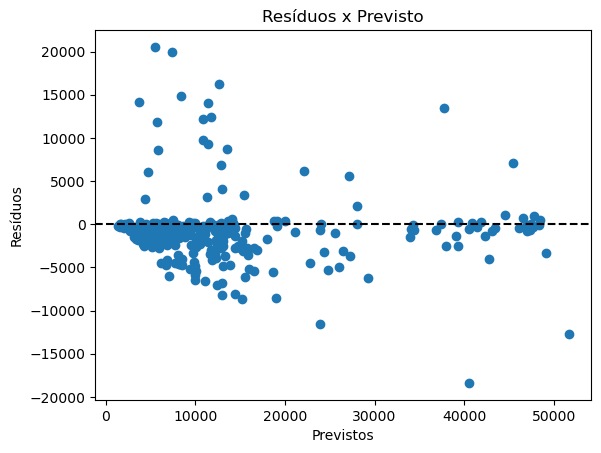

In [ ]:
# Aplicacao do Modelo
model_final = RandomForestRegressor(random_state= 0)
model_final.fit(X_Train, Y_Train)
Y_Prev = model_final.predict(X_Test)

res = Y_Teste - Y_Prev

# grafico de residuos
plt.scatter(Y_Prev, res)
plt.title('Resíduos x Previsto')
plt.axhline(y=0, color='black', linestyle='--') # Linha de erro zero
plt.xlabel('Previstos')
plt.ylabel('Resíduos')
plt.show

O gráfico deixa evidente que esse modelo é o mais apropriado para esses dados, pois ainda que possua alguns valores de residuos elevados, a maioria dos pontos estão proximos a linha 0. 

### C) Importância das Variáveis (Feature Importance)
Explicar os fatores de influência

<function matplotlib.pyplot.show(close=None, block=None)>

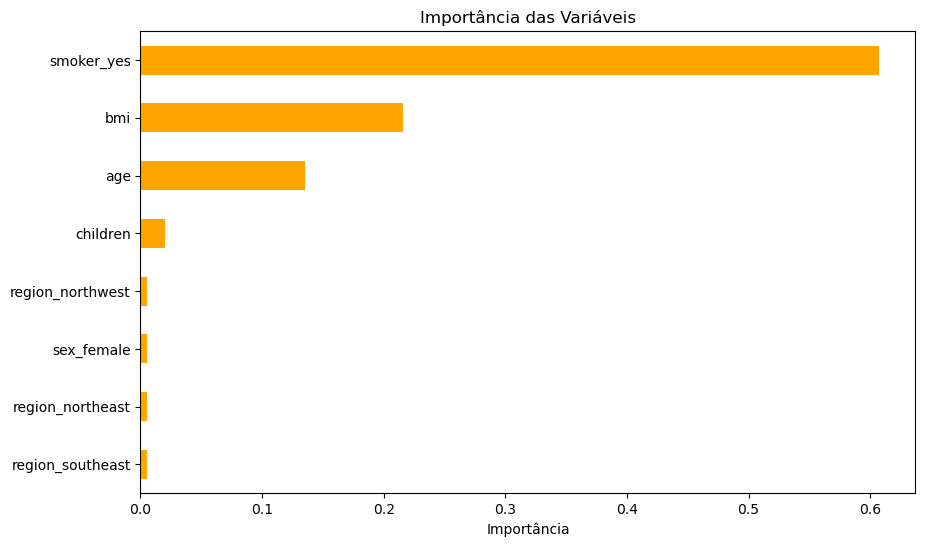

In [44]:
importance = pd.Series(model_final.feature_importances_, index=X.columns)
importance_ord = importance.sort_values(ascending=True)

plt.figure(figsize=(10,6))
importance_ord.plot(kind= 'barh', color = 'orange')
plt.title('Importância das Variáveis')
plt.xlabel('Importância')
plt.show


Conforme já previsto previamente pela Modelagem Estátistíca, a variáveis com maiores influência em custos são, respectivamente, o Hábito de tabagismo, o BMI e a Idade. O que já é esperado dado que o hábito de fumar é muito associada com varias doenças, assim como o IBM e idade elevados.

### D) Erro por segmento
Entender se o modelo pode errar mais ou menos em um grupo.

In [56]:
# Criar um df 
df_check = X_Test.copy()
df_check['Real'] = Y_Teste
df_check['Previsto'] = Y_Prev
df_check["Erro_Abs"] = abs(df_check['Real'] - df_check['Previsto'])

# Analisar o erro medio para fumantes 
erro_smoke = df_check.groupby('smoker_yes')['Erro_Abs'].mean()

#Analisar o erro médio por mulheres
erro_woman = df_check.groupby('sex_female')['Erro_Abs'].mean()

print('Erro Médio Absoluto por Sgemento')
print(f'Fumantes: {erro_smoke[1]:.2f} \nnão Fumantes: {erro_smoke[0]:.2f}')
print(f'Mulheres: {erro_woman[1]:.2f} \nHomens: {erro_woman[0]:.2f}')

Erro Médio Absoluto por Sgemento
Fumantes: 2309.81 
não Fumantes: 2647.70
Mulheres: 2585.42 
Homens: 2572.72


Os valores resultantes mostram que o Erro Médio Absoluto(MAE) entre mulheres e homens é semelhante, ou seja, a perfomance e prediácão do modelo é equilibrada.  
Entretando, os valores de Fumantes x Não Fumantes apresentam um diferença até consideravel, porém coerente para o contexto onde há poucas informações relevantes para o custo quando não fumante.  
Além de que o MAE é altamente influenciável por valores extremos.

# Conclusão Final  
Esse projeto foi feito visando percorrer todo o ciclo de um problema de Ciência de Dados, partindo a Analise exploratoria até Machine Learning.  

**Insigths**  
* A Ánalise das variáveis e o gráfico de importância das variáveis confirmaram que o tabagismo é o fator de maior impacto diante o custo do seguro, seguido pelo BMI e Idade.  
* A relação das variáveis também se mostrou com pouca linearidade, o que justificou o uso de Modelos de ML mais avancados  


**Perfomance de ML**
* O modelo Random Forest superou os demais, com um R² de 0.88 já para o teste.  
* O erro médio absoluto também se estabilizou em pouco mais de 2.500 unidades. Valor aceitavel dado a amplitude de custos de saude.  
* A estabilidade do modelo também foi avaliada com um variação extremamente baixa, cerca de 40 unidades.